In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pipeline import PipelineConfig, run_pipeline, plot_pipeline_results
from simulate import simulate_data
from data_prep import prep_data

In [2]:
"""Data Loading"""

# selecting variables and dates
columns_wanted = ["lnipsa", "lncpi", "r-mkt", "lndem"]
start_date = "1987-01"
end_date = "1998-12"
# setting lags, number of variables, etc
L = 6
C = 5
T = len(pd.date_range(start=start_date, end=end_date, freq="MS"))
N = 4
N_w = 3
N_z = 3
L_w = [0,1]
L_z1 = [1,2]
L_z2 = [0,1]
K = N*L + N_w*len(L_w)
n_lag_z = len(L_z1)  # == len(L_z2)
Z_width = N_z * n_lag_z

# loading data
def load_and_filter(path, columns_wanted):
    df = pd.read_csv(path, index_col=0)
    df.index = pd.to_datetime(df.index, format="%Y-%m")
    df = df[columns_wanted]
    load_start = pd.Timestamp(start_date) - pd.DateOffset(months=L)
    df = df.loc[load_start:end_date]
    return df

fin = load_and_filter("Jarocinski Data/mj-data/2008-euro/finland.csv", columns_wanted)
fra = load_and_filter("Jarocinski Data/mj-data/2008-euro/france.csv", columns_wanted)
ita = load_and_filter("Jarocinski Data/mj-data/2008-euro/italy.csv", columns_wanted)
por = load_and_filter("Jarocinski Data/mj-data/2008-euro/portugal.csv", columns_wanted)
spa = load_and_filter("Jarocinski Data/mj-data/2008-euro/spain.csv", columns_wanted)

wor = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["ffr", "lnoil-eur", "lnnfd-eur"])
ger1 = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["lnipsa-ger"])
ger2 = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["r-mkt-ger", "lneur-usd"])

Y = np.stack([fin.values, fra.values, ita.values, por.values, spa.values], axis=0)
W = wor.values
Z1 = ger1.values
Z2 = ger2.values

In [3]:
config_real = PipelineConfig(
    name="real_data",
    country_names=["Finland", "France", "Italy", "Portugal", "Spain"],
    variable_names=["Output", "Prices", "Interest rate", "Exchange rate"]
)

results_real = run_pipeline(
    Y, W, Z1, Z2, C, N, N_w, T, K, Z_width, L, L_w, L_z1, L_z2,
    config=config_real, force_recompute=True
)

plot_pipeline_results(results_real)

MFVI COMPLETE (14.1s)


KeyboardInterrupt: 

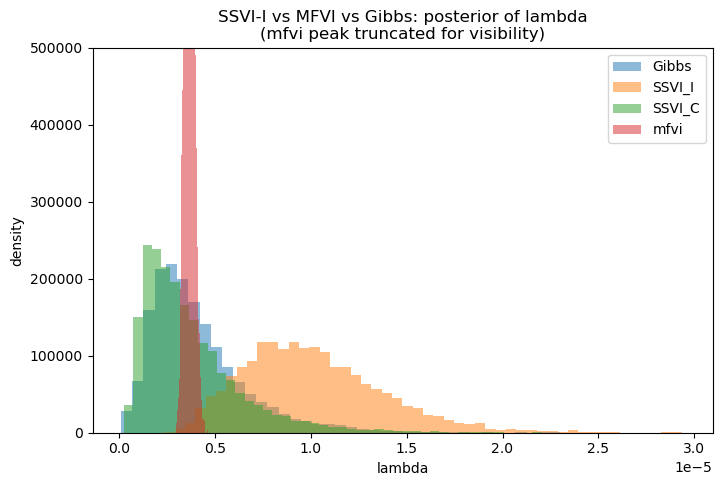

In [6]:
lam_mfvi = results_real["mfvi"]["samples"]["lam"]
lam_ssvi_i = results_real["ssvi_i"]["samples"]["lam"]
lam_ssvi_c = results_real["ssvi_c"]["samples"]["lam"]
lam_gibbs = results_real["gibbs"]["results"]["lam"]


plt.figure(figsize=(8,5))
plt.hist(lam_gibbs, bins=50, density=True, alpha=0.5, label='Gibbs')
plt.hist(lam_ssvi_i, bins=50, density=True, alpha=0.5, label='SSVI_I')
plt.hist(lam_ssvi_c, bins=50, density=True, alpha=0.5, label='SSVI_C')
plt.hist(lam_mfvi, bins=50, density=True, alpha=0.5, label='mfvi')

plt.ylim(0, 500000)  # cap the y-axis so mfvi's spike is cut off
plt.xlabel('lambda')
plt.ylabel('density')
plt.legend()
plt.title('SSVI-I vs MFVI vs Gibbs: posterior of lambda\n(mfvi peak truncated for visibility)')
plt.show()

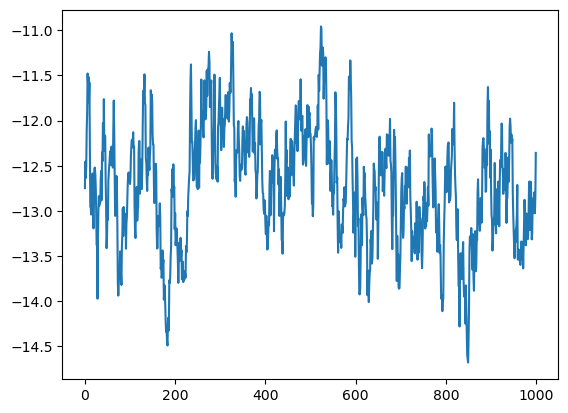

In [16]:
plt.plot(results_real["ssvi_c"]["diagnostics"]["log_lam_history"][-1])

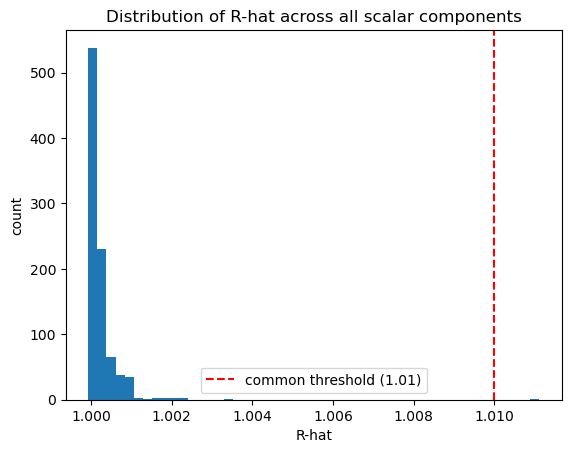

max R-hat: 1.0111
min R-hat: 0.9999
# components with R-hat > 1.01: 1 / 921


In [17]:
rhat = results_real["gibbs"]["diagnostics"]["rhat"]

plt.hist(rhat, bins=50)
plt.axvline(1.01, color='red', linestyle='--', label='common threshold (1.01)')
plt.xlabel('R-hat')
plt.ylabel('count')
plt.title('Distribution of R-hat across all scalar components')
plt.legend()
plt.show()

print(f"max R-hat: {rhat.max():.4f}")
print(f"min R-hat: {rhat.min():.4f}")
print(f"# components with R-hat > 1.01: {(rhat > 1.01).sum()} / {len(rhat)}")

In [19]:
uqf_table = pd.DataFrame({
    method: results_real[method]["uqf"]
    for method in ["mfvi", "ssvi_i", "ssvi_c"]
}, index=config_real.country_names if hasattr(results_real["mfvi"]["uqf"], "__len__") else None)

print(uqf_table.round(4))

            mfvi  ssvi_i  ssvi_c
Finland   0.5244  0.6904  0.6807
France    0.4933  0.6461  0.6869
Italy     0.5169  0.6827  0.6732
Portugal  0.4954  0.6432  0.6757
Spain     0.6036  0.6880  0.6783


In [20]:
results_gibbs = results_real["gibbs"]["results"]

In [ ]:
N = 4
N_w = 3
N_z = 3
L_w = [0,1]
L_z1 = [1,2]
L_z2 = [0,1]
K = N*L + N_w*len(L_w)
n_lag_z = len(L_z1)
Z_width = N_z * len(L_z1)

T_held = 144
C_held = 5
Ts = [30, 300]
Cs = [3, 10]

In [ ]:
true_params_Tlow, Y_sim_Tlow = simulate_data(Y, W, Z1, Z2, results_gibbs,
                   C_held, 30, N, N_w, L, L_w, L_z1, L_z2, K, Z_width, gamma_var = 0.05,
                   burn=50, seed=666)

In [ ]:
mfvi_pack, ssvi_i_pack, gibbs_pack = prep_data(Y_sim_Tlow, W, Z1, Z2, C_held, N, N_w, 30, K, Z_width, L, L_w, L_z1, L_z2)

In [ ]:
results_ssvi_i, ELBO_ssvi_i, ess_list, log_lams_history = run_ssvi_i(ssvi_i_pack, Z_width, C_held, N, K, 30, 
                                                                     n_steps=1000, step_size_init = 0.01, s = 0.2, n_burnin = 100)

In [ ]:
results_ssvi_c, ELBO_ssvi_c, ess_list2, log_lams_history2 = run_ssvi_c(ssvi_i_pack, Z_width, C_held, N, K, 30, 
                                                                       n_steps=1000, step_size_init = 1, s = 0.1, n_burnin = 100)

In [ ]:
true_params_Thigh, Y_sim_Thigh = simulate_data(Y, W, Z1, Z2, results_gibbs,
                   C_held, 300, N, N_w, L, L_w, L_z1, L_z2, K, Z_width, gamma_var = 0.05,
                   burn=50, seed=999)

In [ ]:
true_params_Clow, Y_sim_Clow = simulate_data(Y, W, Z1, Z2, results_gibbs,
                   3, T_held, N, N_w, L, L_w, L_z1, L_z2, K, Z_width, gamma_var = 0.05,
                   burn=50, seed=333)

In [ ]:
true_params_Chigh, Y_sim_Chigh = simulate_data(Y, W, Z1, Z2, results_gibbs,
                   10, T_held, N, N_w, L, L_w, L_z1, L_z2, K, Z_width, gamma_var = 0.05,
                   burn=50, seed=333)

In [89]:
config_sim1 = PipelineConfig(
    name="sim_data_low_T",
    country_names=["A", "B", "C", "D", "E"],
    variable_names=["1", "2", "3", "4"]
)

results_sim1 = run_pipeline(
    Y_sim, W, Z1, Z2, 5, N, N_w, 30, K, Z_width, L, L_w, L_z1, L_z2,
    config=config_sim1,
)

plot_pipeline_results(results_sim1)

MFVI COMPLETE


c:\Users\krrol\github-projects\Research-Project\ssvi_i.py:116: RuntimeWarning: divide by zero encountered in log
  mu_log_q_lambda = -np.mean(np.log(n * diffs / (2*m))) - mu_log_lambda
c:\Users\krrol\github-projects\Research-Project\ssvi_i.py:116: RuntimeWarning: divide by zero encountered in log
  mu_log_q_lambda = -np.mean(np.log(n * diffs / (2*m))) - mu_log_lambda


KeyboardInterrupt: 